In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("Libraries imported.")


Libraries imported.


In [2]:

file_path = "retail_store_inventory.csv"

data = pd.read_csv(file_path)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")

print("Raw head:")
display(data.head())
print("Columns:", list(data.columns))


Raw head:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


Columns: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [3]:

counts = (
    data.groupby(["Store ID", "Product ID"])["Units Sold"]
        .count()
        .sort_values(ascending=False)
)

print("Top 10 (Store ID, Product ID) by count:")
print(counts.head(10))

store_id, product_id = counts.index[0]
print("Using Store ID =", store_id, ", Product ID =", product_id)

df = data[(data["Store ID"] == store_id) & (data["Product ID"] == product_id)].copy()
df.set_index("Date", inplace=True)
df = df.sort_index()

target_col = "Units Sold"

df[target_col] = (
    df[target_col]
      .astype(str)
      .str.replace(",", "", regex=False)
      .astype(float)
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=[target_col], inplace=True)

print("Shape after filter and clean:", df.shape)
display(df.head())
display(df[target_col].describe())


Top 10 (Store ID, Product ID) by count:
Store ID  Product ID
S001      P0001         731
          P0002         731
          P0003         731
          P0004         731
          P0005         731
          P0006         731
          P0007         731
          P0008         731
          P0009         731
          P0010         731
Name: Units Sold, dtype: int64
Using Store ID = S001 , Product ID = P0001
Shape after filter and clean: (731, 14)


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
Date,,,,,,,,,,,,,,
2022-01-01,S001,P0001,Groceries,North,231,127.0,55,135.47,33.50,20,Rainy,0,29.69,Autumn
2022-01-02,S001,P0001,Groceries,West,116,81.0,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2022-01-03,S001,P0001,Electronics,West,154,5.0,189,5.36,62.70,20,Rainy,0,58.22,Winter
2022-01-04,S001,P0001,Groceries,South,85,58.0,193,52.87,77.88,15,Cloudy,1,75.99,Winter
2022-01-05,S001,P0001,Groceries,South,238,147.0,37,150.27,28.46,20,Sunny,1,29.40,Winter


,Units Sold
count,731.000000
mean,137.306430
std,108.187859
min,0.000000
25%,47.000000
50%,109.000000
75%,202.000000
max,461.000000


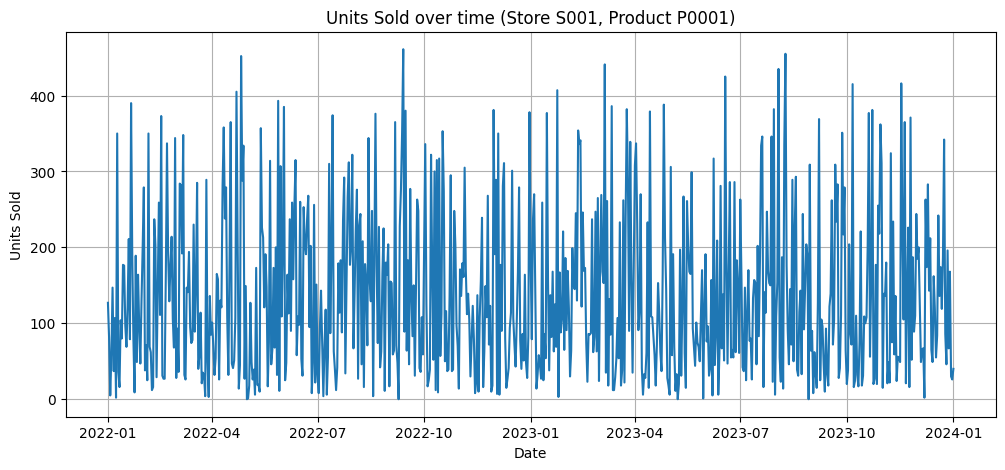

In [4]:

plt.figure()
plt.plot(df.index, df[target_col])
plt.title(f"{target_col} over time (Store {store_id}, Product {product_id})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.show()



ADF test: original series
Length after dropna: 731
ADF Statistic: -27.28239017603455
p-value: 0.0
# Lags Used: 0
# Observations Used: 730
Critical Value (1%): -3.4393
Critical Value (5%): -2.8655
Critical Value (10%): -2.5689
Reject H0: series is stationary.


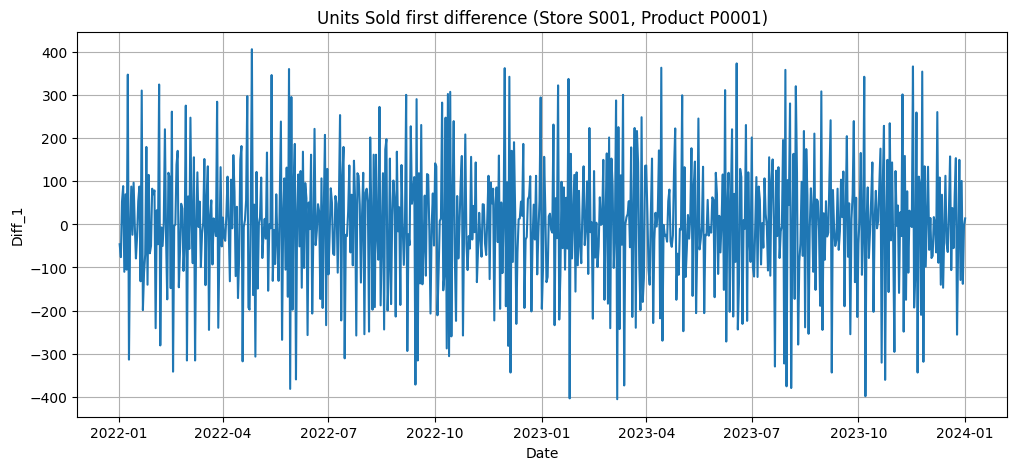


ADF test: first difference
Length after dropna: 730
ADF Statistic: -10.39251037572229
p-value: 2.0038709314344373e-18
# Lags Used: 20
# Observations Used: 709
Critical Value (1%): -3.4396
Critical Value (5%): -2.8656
Critical Value (10%): -2.5689
Reject H0: series is stationary.


In [5]:

def adf_test(series, title=""):
    s = pd.Series(series).dropna()
    print("\nADF test:", title)
    print("Length after dropna:", len(s))
    if len(s) < 10:
        print("Series too short for ADF.")
        return
    result = adfuller(s)
    labels = ["ADF Statistic", "p-value", "# Lags Used", "# Observations Used"]
    out = dict(zip(labels, result[0:4]))
    for k, v in out.items():
        print(k + ":", v)
    for key, value in result[4].items():
        print("Critical Value (" + key + "):", round(value, 4))
    if result[1] <= 0.05:
        print("Reject H0: series is stationary.")
    else:
        print("Fail to reject H0: series is non-stationary.")

adf_test(df[target_col], title="original series")

df["Diff_1"] = df[target_col].diff()

plt.figure()
plt.plot(df.index, df["Diff_1"])
plt.title(f"{target_col} first difference (Store {store_id}, Product {product_id})")
plt.xlabel("Date")
plt.ylabel("Diff_1")
plt.show()

adf_test(df["Diff_1"], title="first difference")


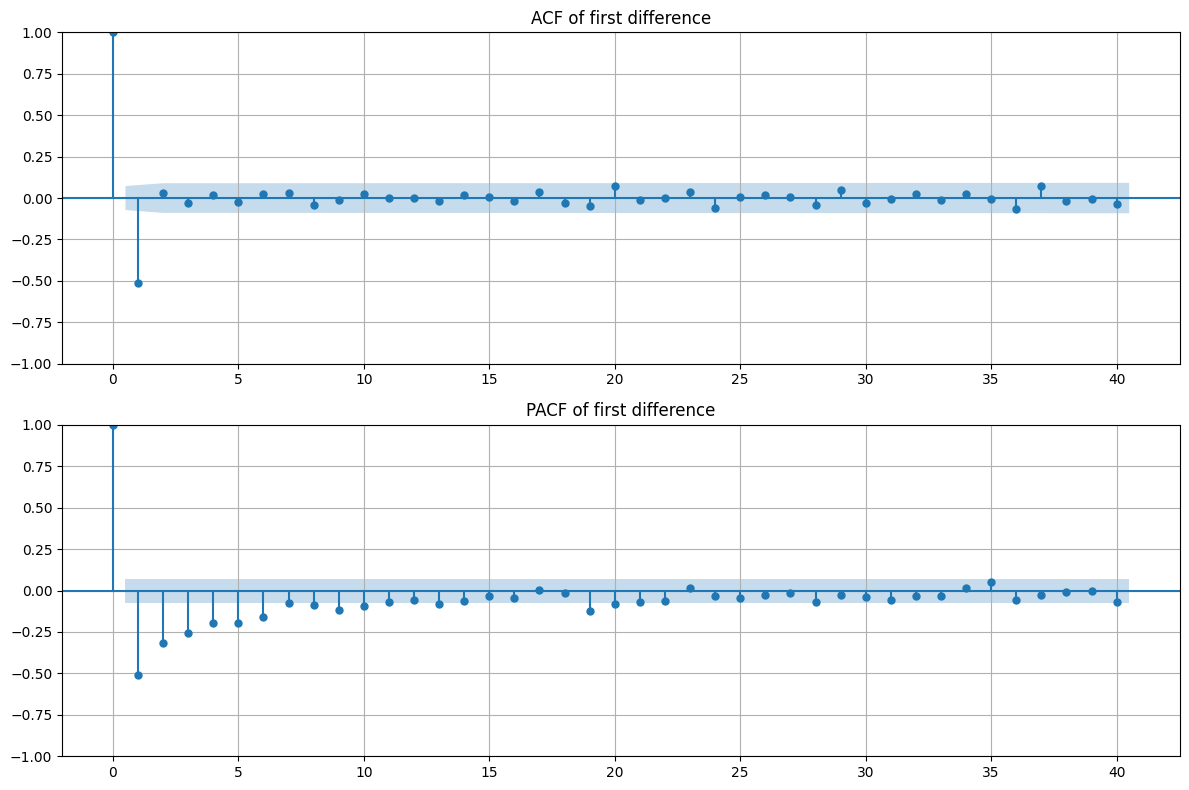

Using ARIMA order: (1, 1, 1)


In [6]:

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df["Diff_1"].dropna(), lags=40, ax=ax[0])
ax[0].set_title("ACF of first difference")
plot_pacf(df["Diff_1"].dropna(), lags=40, ax=ax[1], method="ywm")
ax[1].set_title("PACF of first difference")
plt.tight_layout()
plt.show()

p, d, q = 1, 1, 1
print("Using ARIMA order:", (p, d, q))


Train length: 584 Test length: 147


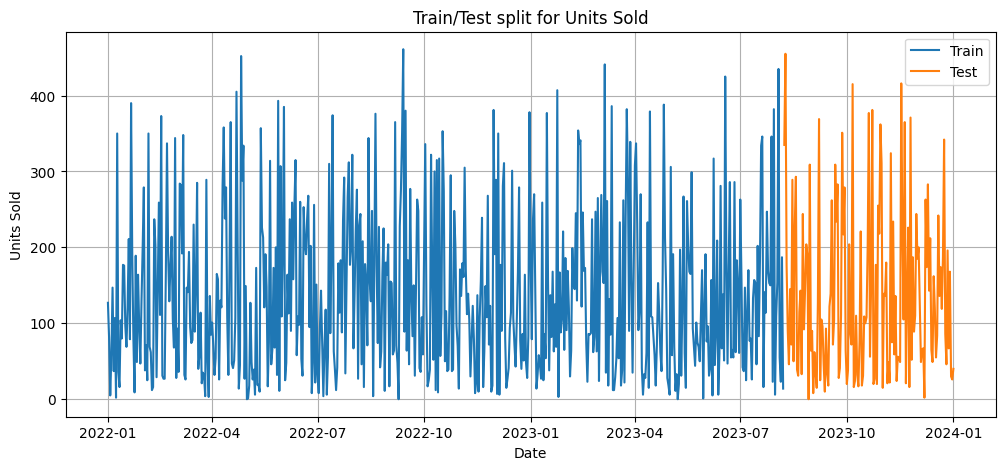

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Units Sold   No. Observations:                  584
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3559.145
Date:                Thu, 27 Nov 2025   AIC                           7124.290
Time:                        13:50:28   BIC                           7137.394
Sample:                    01-01-2022   HQIC                          7129.397
                         - 08-07-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0115      0.042     -0.271      0.786      -0.094       0.071
ma.L1         -0.9998      0.192     -5.215      0.000      -1.376      -0.624
sigma2      1.163e+04   2228.472      5.218      0.0

In [7]:

ts = df[target_col].copy()

train_size = int(len(ts) * 0.8)
train, test = ts.iloc[:train_size], ts.iloc[train_size:]

print("Train length:", len(train), "Test length:", len(test))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.title(f"Train/Test split for {target_col}")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.show()

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())


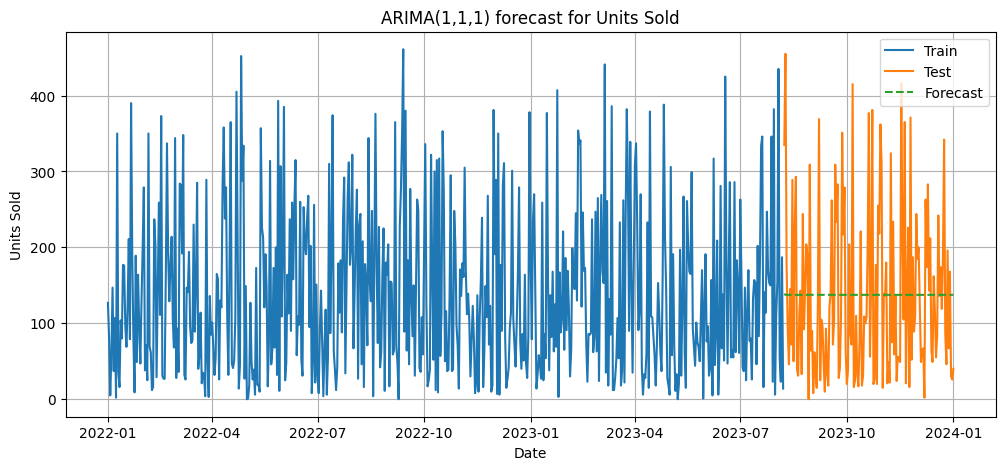

AIC: 7124.289534450053
BIC: 7137.394096009104
RMSE: 109.58168989013183


,Store ID,Product ID,p,d,q,AIC,BIC,RMSE
0,S001,P0001,1,1,1,7124.289534,7137.394096,109.58169


In [8]:

n_test = len(test)
forecast = model_fit.forecast(steps=n_test)
forecast.index = test.index

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(forecast.index, forecast, label="Forecast", linestyle="--")
plt.title(f"ARIMA({p},{d},{q}) forecast for {target_col}")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.show()

aic = model_fit.aic
bic = model_fit.bic
rmse = float(np.sqrt(mean_squared_error(test, forecast)))

print("AIC:", aic)
print("BIC:", bic)
print("RMSE:", rmse)

summary_table = pd.DataFrame({
    "Store ID": [store_id],
    "Product ID": [product_id],
    "p": [p],
    "d": [d],
    "q": [q],
    "AIC": [aic],
    "BIC": [bic],
    "RMSE": [rmse]
})
display(summary_table)


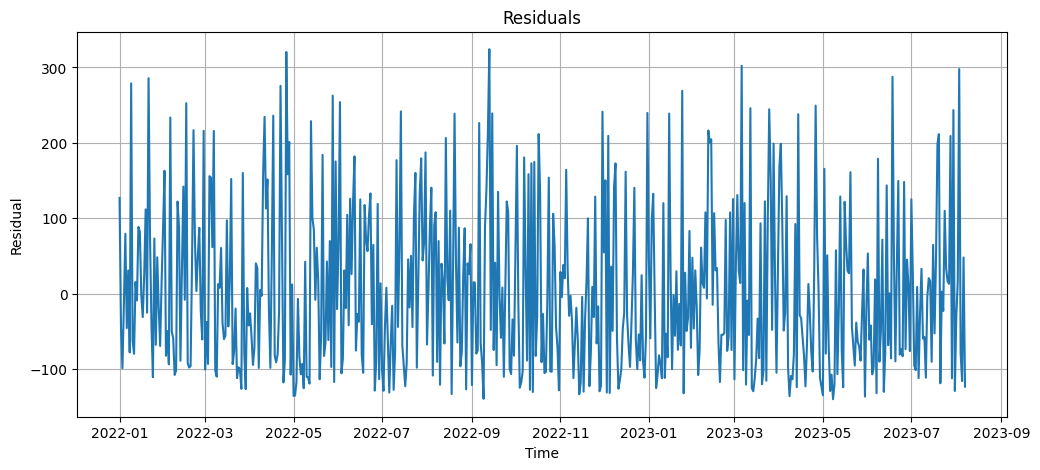

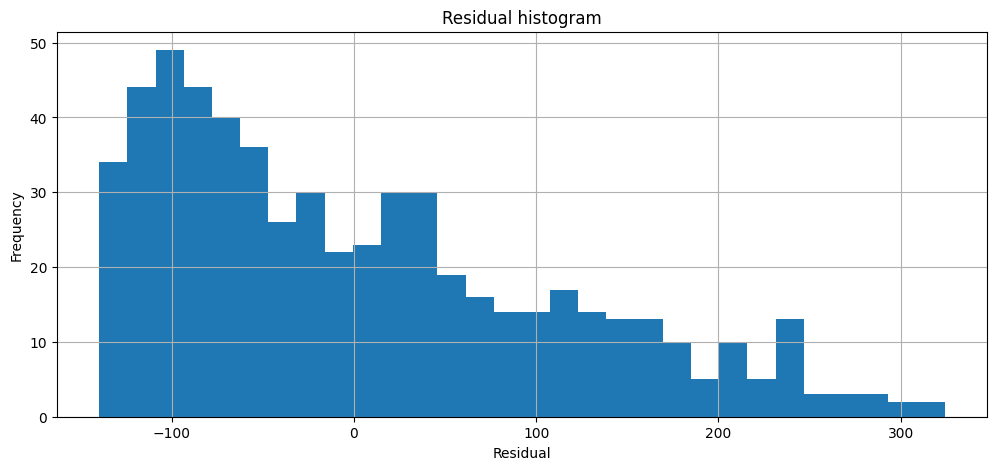

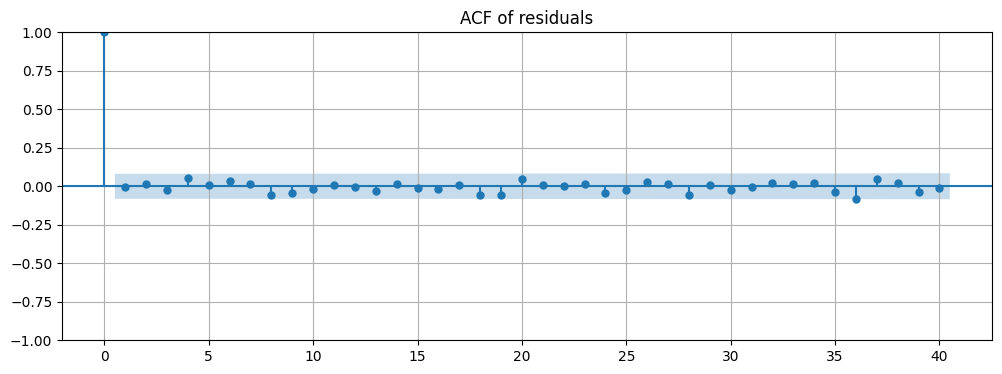

In [9]:

residuals = model_fit.resid

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual histogram")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_acf(residuals.dropna(), lags=40, ax=ax)
ax.set_title("ACF of residuals")
plt.show()
